# Development 4: ground truth from LiDAR, and a visual trust check

Builds true depth for the camera by projecting LiDAR points into the image,
then shows pictures so the result can be judged by eye BEFORE any metric uses
it. No model, no GPU: a CPU server is enough.

Cell 4 downloads the LiDAR layer this time (about 8.8 GB for the block on a
fresh server, a few minutes). What to look for is written above each figure.

In [5]:
# --- 1. Configuration ---
PERSIST_MODE = "drive"
SPLIT, BLOCK = "val", 11
LAYERS = ["camera_keyframes", "lidar_motion_compensated_keyframes"]   # every layer wanted, every time
SCENE_ID = "2025-06-13-07-09-37|78"
CAMERA = "front_medium"
WIDE_CAMERA = "front_wide"          # widest lens: where lens distortion would show first
CHECK_FRAMES = [0, 13, 26, 39]      # frames used for the pictures and the comparison tables

In [ ]:
# === CODE SYNC (auto-generated by `python -m vggt_aura.sync`, do not edit) ===
raise RuntimeError("The sync cell is empty. On your own machine, in the project folder, run:  python -m vggt_aura.sync   and reopen this notebook.")

In [7]:
# --- 3. Start the session (no GPU needed) ---
from vggt_aura.session import start_session

session = start_session(persist_mode=PERSIST_MODE, require_gpu=False)

GPU: none (fine for download and inspection)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
persist root: /content/drive/MyDrive/vggt-omega-aura-benchmark
data root   : /content/data/fzi-aura (runtime disk, wiped at session end)


In [8]:
# --- 4. Make sure camera AND LiDAR layers of the block are on this runtime ---
import time
from vggt_aura import aura_data as ad, inference as inf, geometry as geo, ground_truth as gtm, pins

chunks, scene_blocks, hub_files = ad.fetch_release_tables(session.data_root / "_release_tables")
BLOCK_SCENE_IDS = ad.block_scene_ids(scene_blocks, SPLIT, BLOCK)
if ad.block_on_disk(session.data_root, BLOCK_SCENE_IDS, LAYERS):
    print("block already on disk with", LAYERS)
else:
    started = time.time()
    ad.download_block(session.data_root, SPLIT, BLOCK, BLOCK_SCENE_IDS, LAYERS)
    print(f"download and extract took {(time.time() - started) / 60:.1f} min")

$ /usr/bin/python3 -m fzi_aura.download /content/data/fzi-aura --revision 3404bd6b8fcd6eed53a0ec7610650a6393aabb49 --splits val --scene-ids-file /content/data/fzi-aura/_scene_ids_val_block000011.txt --layers camera_keyframes,lidar_motion_compensated_keyframes --jobs 8 --verify
download and extract took 7.5 min


In [9]:
# --- 5. What is in a LiDAR sweep? Fields, sizes, and whether points carry their own time (trap 3) ---
import json
import numpy as np
import pandas as pd
from fzi_aura import FZIAURADataset

pd.set_option("display.width", 220)
dataset = FZIAURADataset(session.data_root, split=SPLIT)
scene = dataset.get_scene(SCENE_ID)
frames = inf.select_frames(scene, CAMERA)
LIDARS = list(scene.available_lidars())
frame0 = frames[0]
print("scene:", scene.scene_id, "| keyframes:", len(frames), "| lidars on disk:", LIDARS)

rows = []
for lidar_id in LIDARS:
    cloud = frame0.load_lidar(lidar_id, stage=gtm.STAGE)
    ranges = np.linalg.norm(cloud.xyz, axis=1)
    rows.append({"lidar": lidar_id, "points": len(cloud), "fields": ", ".join(cloud.field_names),
                 "range_m_median": round(float(np.median(ranges)), 1), "range_m_p99": round(float(np.percentile(ranges, 99)), 1),
                 "mount_in_base_link_m": frame0.calibration().base_from_sensor(f"lidar/{lidar_id}")[:3, 3].round(2).tolist()})
print(pd.DataFrame(rows).to_string(index=False))
print()
cloud = frame0.load_lidar(LIDARS[0], stage=gtm.STAGE)
for name in cloud.field_names:
    values = np.asarray(cloud.field(name))
    if values.ndim == 1 and values.dtype.kind in "fiu":
        print(f"  field {name!r:14} dtype {str(values.dtype):8} min {values.min():.6g}  max {values.max():.6g}")
time_like = [n for n in cloud.field_names if any(key in n.lower() for key in ("time", "stamp")) or n.lower() == "t"]
print("per-point time fields:", time_like or "NONE FOUND")
camera_position = frame0.calibration().base_from_sensor(f"camera/{CAMERA}")[:3, 3]
print("camera mount in base_link, m:", camera_position.round(2).tolist())

scene: 2025-06-13-07-09-37|78 | keyframes: 40 | lidars on disk: ['front_left', 'front_right', 'rear_left', 'rear_right', 'top_left', 'top_right']
      lidar  points                                fields  range_m_median  range_m_p99 mount_in_base_link_m
 front_left   57601 x, y, z, t, reflectivity, ring, range             8.9         53.8   [1.64, 0.56, 1.46]
front_right   62071 x, y, z, t, reflectivity, ring, range             6.7         38.1   [1.64, -0.6, 1.48]
  rear_left   57265 x, y, z, t, reflectivity, ring, range             9.6         71.5  [-0.21, 0.56, 1.44]
 rear_right   61852 x, y, z, t, reflectivity, ring, range             6.9         48.6   [-0.2, -0.6, 1.46]
   top_left   60941 x, y, z, t, reflectivity, ring, range            18.3        136.3   [0.61, 0.38, 1.71]
  top_right   69443 x, y, z, t, reflectivity, ring, range            10.1        103.3   [0.6, -0.41, 1.72]

  field 'x'            dtype float32  min -140.146  max 45.3823
  field 'y'            dtype floa

In [10]:
# --- 6. Sizes and calibration for the two image sizes used below ---
classes = json.loads((scene.path / "labels" / "semantic" / "classes.json").read_text(encoding="utf-8"))
CLASS_NAMES = {int(c["id"]): c["name"] for c in classes["semantic_classes"]}
DROP_IDS = gtm.excluded_class_ids(CLASS_NAMES)
print("classes dropped from ground truth:", {i: CLASS_NAMES[i] for i in sorted(DROP_IDS)})

npz_path, json_path = inf.prediction_paths(session.persist_root, scene.name, CAMERA, pins.CHECKPOINT_PUBLIC_512)
if npz_path.is_file():
    MODEL_H, MODEL_W = (int(v) for v in inf.load_predictions(npz_path, json_path)[0]["input_hw"])
    print("model input size read from the saved predictions:", MODEL_W, "x", MODEL_H)
else:
    MODEL_W, MODEL_H = 640, 400
    print("no saved predictions found, using the computed model input size:", MODEL_W, "x", MODEL_H)


def intrinsics_for(camera_id, width=None, height=None):
    """(fx, fy, cx, cy) at the native size, or scaled per axis to width x height."""
    calibration = scene.calibration()
    P = calibration.camera_projection_matrix(camera_id)
    native = calibration.sensor(f"camera/{camera_id}")["intrinsics"]
    native_wh = (native["width"], native["height"])
    if width is None:
        return (P[0, 0], P[1, 1], P[0, 2], P[1, 2]), native_wh
    return geo.scale_intrinsics(P[0, 0], P[1, 1], P[0, 2], P[1, 2], native_wh, (width, height)), native_wh


MODEL_K, NATIVE_WH = intrinsics_for(CAMERA, MODEL_W, MODEL_H)
print("native", NATIVE_WH, "-> model", (MODEL_W, MODEL_H), "| scaled fx fy cx cy:", np.round(MODEL_K, 2).tolist())

classes dropped from ground truth: {27: 'noise', 31: 'ego'}
model input size read from the saved predictions: 640 x 400
native (1920, 1200) -> model (640, 400) | scaled fx fy cx cy: [538.2, 564.73, 324.75, 196.27]


In [11]:
# --- 7. The three occlusion rules on the same frames: how much does each remove, and WHAT? ---
MODES = {mode: gtm.OcclusionParams(mode=mode) for mode in gtm.OCCLUSION_MODES}
print("parameters:", MODES["two_sided"].as_dict())

loaded_frames = {i: gtm.load_points_in_camera(frames[i], CAMERA, LIDARS) for i in CHECK_FRAMES}
truth = {mode: {i: gtm.build_ground_truth(loaded_frames[i], MODEL_K, MODEL_W, MODEL_H, p, DROP_IDS)
                for i in CHECK_FRAMES} for mode, p in MODES.items()}

summary = []
for mode in MODES:
    counts = pd.DataFrame([truth[mode][i]["counts"] for i in CHECK_FRAMES]).sum()
    summary.append({"mode": mode, "candidates": int(counts["candidates"]),
                    "occluded_share": round(counts["dropped_as_occluded"] / counts["candidates"], 4),
                    "same_pixel_share": round(counts["dropped_same_pixel"] / counts["candidates"], 4),
                    "pixels_with_truth": int(counts["pixels_with_ground_truth"]),
                    "image_coverage": round(counts["pixels_with_ground_truth"] / (len(CHECK_FRAMES) * MODEL_W * MODEL_H), 4)})
print(pd.DataFrame(summary).to_string(index=False))
print("occluded   = dropped by the occlusion rule (the part that can be wrong)")
print("same_pixel = a nearer point shares the pixel; never changes the result, since only the nearest per pixel is used")

for mode in ("window", "two_sided"):
    tables = [gtm.removal_table(loaded_frames[i], truth[mode][i], CLASS_NAMES) for i in CHECK_FRAMES]
    by_class = pd.concat([c for c, _ in tables]).groupby(level=0).sum()
    by_band = pd.concat([b for _, b in tables]).groupby(level=0, observed=False).sum()
    for table in (by_class, by_band):
        table["occluded_share"] = (table["occluded"] / table["points"]).round(3)
    print()
    print(f"===== mode {mode!r}: share of points dropped by the occlusion rule =====")
    print(by_class.sort_values("points", ascending=False).head(12)[["points", "occluded_share"]].to_string())
    print(by_band[["points", "occluded_share"]].to_string())
print()
print("READ THIS: a rule that drops a large share of far 'road' points is deleting a slanted surface, not an occlusion.")

parameters: {'mode': 'two_sided', 'radius': 6, 'half_width': 0, 'rel_tol': 0.1, 'abs_tol': 0.5, 'min_depth': 1.0}
     mode  candidates  occluded_share  same_pixel_share  pixels_with_truth  image_coverage
     none      193817          0.0000            0.0000             169914          0.1659
   window      193817          0.1423            0.0127             145624          0.1422
two_sided      193817          0.0272            0.0127             164936          0.1611
occluded   = dropped by the occlusion rule (the part that can be wrong)
same_pixel = a nearer point shares the pixel; never changes the result, since only the nearest per pixel is used

===== mode 'window': share of points dropped by the occlusion rule =====
            points  occluded_share
class                             
road         70688           0.091
vegetation   69154           0.155
sidewalk     17832           0.194
building     15295           0.266
fence         6586           0.077
car           3839

## Figure A: is the calibration right, and are the images undistorted?

Naive projection at FULL resolution, no occlusion handling. **Look for:** LiDAR
dots sitting exactly on what they hit. Poles, kerbs, car outlines and building
edges should line up everywhere, including the far left and right of the image.
Dots that drift off their objects toward the borders would mean the JPGs still
carry lens distortion that the calibration file does not describe.

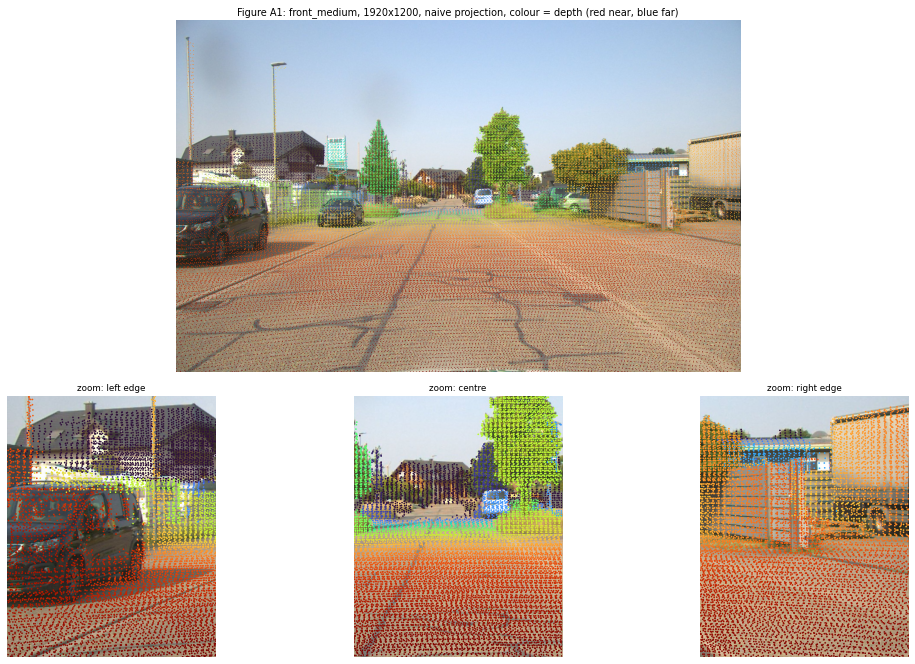

In [12]:
# --- 8. Figure A: full-resolution overlay, plus three native-resolution zooms ---
import matplotlib.pyplot as plt

figure_dir = session.persist_root / "figures" / "phase4"
figure_dir.mkdir(parents=True, exist_ok=True)
NONE = gtm.OcclusionParams(mode="none")


def overlay_native(camera_id, frame, title):
    K, (native_w, native_h) = intrinsics_for(camera_id)
    loaded = gtm.load_points_in_camera(frame, camera_id, LIDARS)
    t = gtm.build_ground_truth(loaded, K, native_w, native_h, NONE, DROP_IDS)
    image = frame.load_camera(camera_id)
    boxes = {"left edge": (0, native_w // 4), "centre": (native_w * 3 // 8, native_w * 5 // 8),
             "right edge": (native_w * 3 // 4, native_w)}
    figure = plt.figure(figsize=(15, 9.6), dpi=70)
    grid = figure.add_gridspec(2, 3, height_ratios=[1.35, 1])
    axis = figure.add_subplot(grid[0, :])
    axis.imshow(image)
    axis.scatter(t["u"], t["v"], c=np.clip(t["depth_m"], 0, 60), cmap="turbo_r", s=0.6, linewidths=0)
    axis.set_title(f"{title}: {camera_id}, {native_w}x{native_h}, naive projection, colour = depth (red near, blue far)", fontsize=10)
    axis.axis("off")
    band = (native_h * 3 // 10, native_h * 8 // 10)
    for column, (name, (u0, u1)) in enumerate(boxes.items()):
        axis = figure.add_subplot(grid[1, column])
        keep = (t["u"] >= u0) & (t["u"] < u1) & (t["v"] >= band[0]) & (t["v"] < band[1])
        axis.imshow(image[band[0]:band[1], u0:u1])
        axis.scatter(t["u"][keep] - u0, t["v"][keep] - band[0], c=np.clip(t["depth_m"][keep], 0, 60),
                     cmap="turbo_r", s=3, linewidths=0)
        axis.set_title(f"zoom: {name}", fontsize=9)
        axis.axis("off")
    figure.tight_layout()
    figure.savefig(figure_dir / f"{scene.name}_{camera_id}_overlay.png", dpi=70)
    plt.show()


overlay_native(CAMERA, frames[CHECK_FRAMES[0]], "Figure A1")

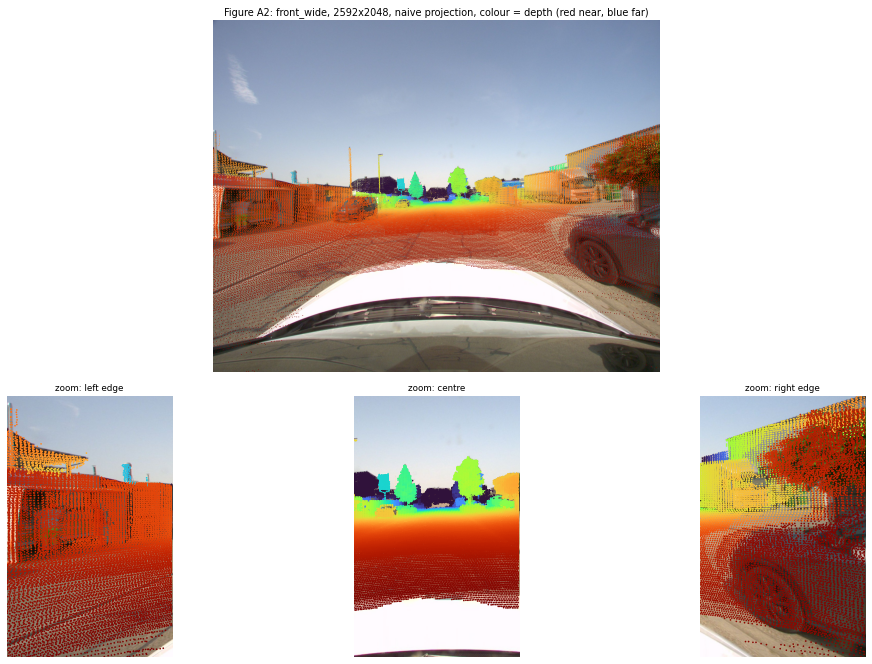

In [13]:
# --- 9. Figure A2: the same check on the widest camera, where distortion would be largest ---
wide_frames = inf.select_frames(scene, WIDE_CAMERA)
overlay_native(WIDE_CAMERA, wide_frames[CHECK_FRAMES[0]], "Figure A2")

## Figure B: does the occlusion rule do the right thing?

Model-input size. Kept points are coloured by depth; **dropped points are
magenta**. **Look for:**

- `none`: far-coloured (blue) dots INSIDE the outlines of near objects such as
  parked cars, trunks and poles. That is the corruption being fixed.
- `window`: magenta all over the far road. That is the simple rule deleting a
  slanted surface, the failure described in `ground_truth.py`.
- `two_sided`: magenta only inside or hugging foreground outlines, and the far
  road left alone. If the far road turns magenta here too, the rule is wrong
  and must not be used.

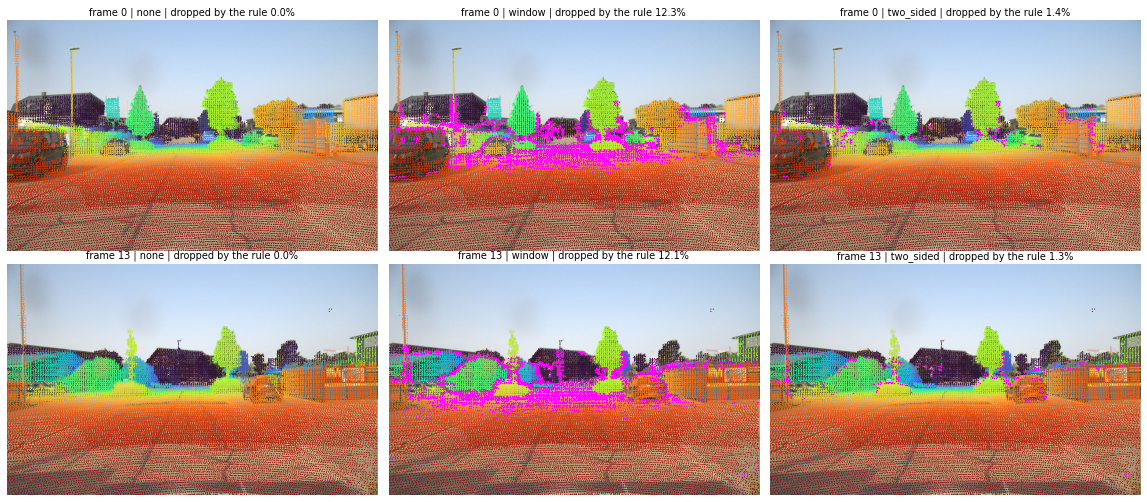

In [14]:
# --- 10. Figure B: three rules side by side on two frames ---
from PIL import Image

show_frames = [CHECK_FRAMES[0], CHECK_FRAMES[1]]
figure, axes = plt.subplots(len(show_frames), 3, figsize=(16.5, 3.6 * len(show_frames)), dpi=70)
for row, i in enumerate(show_frames):
    image = np.asarray(Image.open(frames[i].camera_path(CAMERA)).convert("RGB").resize((MODEL_W, MODEL_H)))
    loaded = loaded_frames[i]
    u, v, z = gtm.project_pinhole(loaded["points_cam"], *MODEL_K)
    ui, vi, _ = gtm.pixel_indices(u, v, MODEL_W, MODEL_H)
    for column, mode in enumerate(gtm.OCCLUSION_MODES):
        t = truth[mode][i]
        index, reason = t["candidate_index"], t["reason"]
        visible, dropped = reason == gtm.VISIBLE, reason == gtm.HIDDEN_BY_NEIGHBOURS   # same-pixel drops are not drawn
        axis = axes[row, column]
        axis.imshow(image)
        axis.scatter(ui[index][visible], vi[index][visible], c=np.clip(z[index][visible], 0, 60),
                     cmap="turbo_r", s=1.2, linewidths=0)
        axis.scatter(ui[index][dropped], vi[index][dropped], c="magenta", s=2.0, linewidths=0)
        axis.set_title(f"frame {i} | {mode} | dropped by the rule {100 * dropped.mean():.1f}%", fontsize=10)
        axis.axis("off")
figure.tight_layout()
figure.savefig(figure_dir / f"{scene.name}_{CAMERA}_occlusion_modes.png", dpi=70)
plt.show()

In [15]:
# --- 11. Build and save ground truth for every keyframe of the scene (rule: two_sided) ---
started = time.time()
PARAMS = gtm.OcclusionParams(mode="two_sided")
scene_truth = [gtm.build_ground_truth(gtm.load_points_in_camera(f, CAMERA, LIDARS), MODEL_K, MODEL_W, MODEL_H, PARAMS, DROP_IDS)
               for f in frames]
truth_npz, truth_json = gtm.truth_paths(session.persist_root, scene.name, CAMERA)
meta = {"scene_id": SCENE_ID, "camera": CAMERA, "lidars": LIDARS, "stage": gtm.STAGE,
        "model_wh": [MODEL_W, MODEL_H], "native_wh": list(NATIVE_WH), "intrinsics_fx_fy_cx_cy": [float(x) for x in MODEL_K],
        "occlusion": PARAMS.as_dict(), "dropped_classes": {str(i): CLASS_NAMES[i] for i in sorted(DROP_IDS)},
        "aggregation": "nearest visible point per pixel", "depth": "Z in the camera frame, metres",
        "dataset_revision": pins.AURA_DATASET_REVISION}
size_mb = gtm.save_scene_truth(truth_npz, truth_json, scene_truth, [f.timestamp_ns for f in frames], meta)
session.manifest.mark_done(SCENE_ID, f"ground_truth/{CAMERA}", file=str(truth_npz.relative_to(session.persist_root)))

per_frame = np.array([len(t["depth_m"]) for t in scene_truth])
depths = np.concatenate([t["depth_m"] for t in scene_truth])
semantic = np.concatenate([t["semantic_id"] for t in scene_truth])
print(f"{len(frames)} frames in {time.time() - started:.0f} s | saved {size_mb:.1f} MB -> {truth_npz}")
print("pixels with ground truth per frame: min %d | median %d | max %d  (%.1f%% of the image at the median)"
      % (per_frame.min(), np.median(per_frame), per_frame.max(), 100 * np.median(per_frame) / (MODEL_W * MODEL_H)))
print("ground-truth depth, metres: p5 %.1f | median %.1f | p95 %.1f | max %.1f" % (*np.percentile(depths, [5, 50, 95]), depths.max()))
shares = pd.Series(semantic).map(CLASS_NAMES).value_counts(normalize=True).head(10).round(3)
print("class share of ground-truth pixels:")
print(shares.to_string())

40 frames in 6 s | saved 7.6 MB -> /content/drive/MyDrive/vggt-omega-aura-benchmark/ground_truth/2025-06-13-07-09-37_78/front_medium.npz
pixels with ground truth per frame: min 37694 | median 42585 | max 46973  (16.6% of the image at the median)
ground-truth depth, metres: p5 4.8 | median 13.3 | p95 58.1 | max 259.8
class share of ground-truth pixels:
vegetation      0.384
road            0.369
building        0.084
sidewalk        0.077
car             0.020
parking         0.019
fence           0.019
static          0.005
pole            0.004
traffic sign    0.004
